# L0.1 — Variables & Functions

Hands-on notebook for the lesson [`0-1-variables-functions.mdx`](../../llm-quest-theory/level-0/0-1-variables-functions.mdx).

> **Learning objectives**
> - Understand a function as a "machine" that turns input `x` into output `y = f(x)`.
> - Plot and read the graphs of 4 basic functions: linear, quadratic, exponential, sine.
> - Answer the 3 quick-check questions at the end of the theory.

## Connection to the theory
This notebook covers sections **§1–§5** of the source `.mdx`. Key idea: an ML model is also just a function `f` with many parameters.

In [1]:
# ---- Setup ----
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A function is a "machine"

Each Python function below corresponds to a formula from the theory. We will call them, then plot their graphs.

$$f_1(x)=ax+b,\quad f_2(x)=x^2,\quad f_3(x)=e^x,\quad f_4(x)=\sin x$$

In [2]:
def linear(x, a=2.0, b=1.0):
    return a * x + b

def quadratic(x):
    return x ** 2

def exponential(x):
    return np.exp(x)

def sine(x):
    return np.sin(x)

# Try with a single value
print("linear(3) =", linear(3))
print("quadratic(3) =", quadratic(3))
print("exponential(1) =", exponential(1))
print("sine(pi/2) =", sine(np.pi / 2))

linear(3) = 7.0
quadratic(3) = 9
exponential(1) = 2.718281828459045
sine(pi/2) = 1.0


## 2. Plot all 4 graphs side by side
Observe: which function grows fastest? Which is periodic? Which is symmetric?

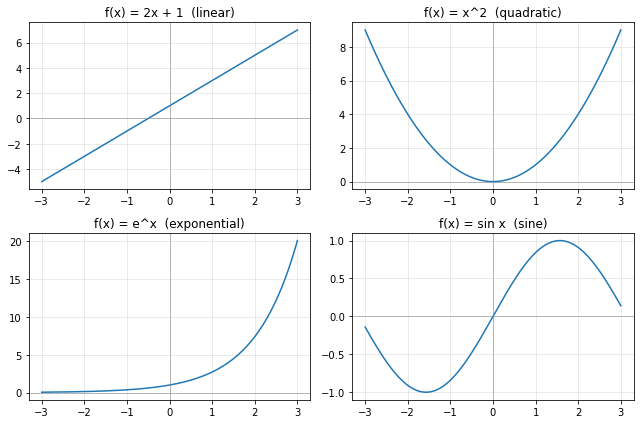

In [3]:
x = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes = axes.ravel()

axes[0].plot(x, linear(x, 2, 1));      axes[0].set_title("f(x) = 2x + 1  (linear)")
axes[1].plot(x, quadratic(x));         axes[1].set_title("f(x) = x^2  (quadratic)")
axes[2].plot(x, exponential(x));       axes[2].set_title("f(x) = e^x  (exponential)")
axes[3].plot(x, sine(x));              axes[3].set_title("f(x) = sin x  (sine)")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Sweep the parameters `a`, `b`
Instead of a widget slider, we plot several lines at once to "see" how `a` (slope) and `b` (intercept) act.

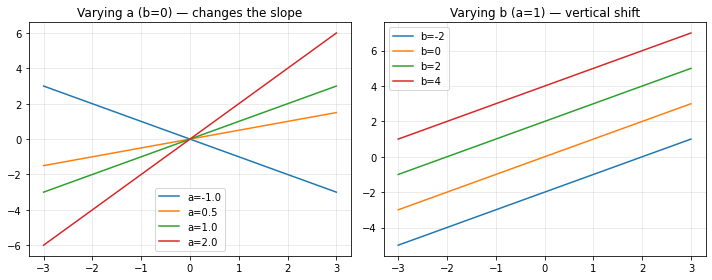

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for a in [-1.0, 0.5, 1.0, 2.0]:
    ax1.plot(x, linear(x, a=a, b=0), label=f"a={a}")
ax1.set_title("Varying a (b=0) — changes the slope")
ax1.legend(); ax1.grid(alpha=0.3)

for b in [-2, 0, 2, 4]:
    ax2.plot(x, linear(x, a=1.0, b=b), label=f"b={b}")
ax2.set_title("Varying b (a=1) — vertical shift")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. Quick check (from theory §5)

Given `f(x) = 3x + 2`. Compute `f(0), f(1), f(-2)` and the slope.

In [5]:
f = lambda x: 3 * x + 2
for v in [0, 1, -2]:
    print(f"f({v}) = {f(v)}")

slope = f(1) - f(0)  # change when x goes up by 1
print("Delta f when x increases by 1 =", slope, "-> slope = 3 (matches the x coefficient)")

f(0) = 2
f(1) = 5
f(-2) = -4
Delta f when x increases by 1 = 3 -> slope = 3 (matches the x coefficient)


## 5. Connection to ML

- An ML **model** is in essence a function `f_theta(x)` where `theta` is the set of learnable parameters.
- Deep learning = a function `f` with many parameters, composed from simple linear and non-linear pieces.
- An LLM = a function `f_theta(token_sequence)` that returns a probability distribution over the next token.

## Reflection questions

1. When `a` changes sign, how does the graph of `y = ax + b` change?
2. Why is `e^x` so often cited as an example of "explosive growth"?
3. If we call a model a "machine that maps input → output", what is "training" doing to that machine?

## References
- Source theory: [`0-1-variables-functions.mdx`](../../llm-quest-theory/level-0/0-1-variables-functions.mdx)
- 3Blue1Brown — *Essence of Calculus* (YouTube)